# 大作业1


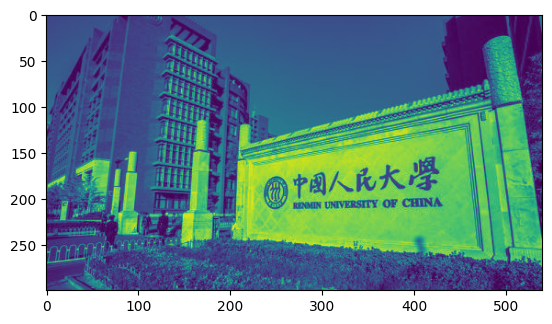

In [95]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

#输入图像
im = np.array(Image.open('ruc.jpg').convert('L'))
plt.imshow(im)
plt.show()
# im是输入图像转换成的list
im = im.tolist()

# ker是卷积核对应的list
ker = np.array([[1,1,1,-1,-1],
                [1,0,0,0,-1],
                [1,0,0,0,-1],
                [1,0,0,0,-1],
                [1,1,1,-1,-1]])

ker = ker.tolist()

In [96]:
def conv2d(im, kernel, stride): 
    im = np.array(im)
    kernel = np.array(kernel)
    #获得矩阵大小
    h_im, w_im = im.shape
    h_ker, w_ker = kernel.shape
    #对矩阵k的翻转
    k_1 = np.zeros_like(kernel)
    for i in range(h_ker):
        for j in range(w_ker):
            k_1[i][j] = kernel[h_ker-1-i][w_ker-1-j]
    #按指定步长在不同位置计算响应值
    ## 计算im_out[a][b]位置的数值
    i = 0
    j = 0 #im[i][j]是im矩阵中ker左上角的位置
    a = 0
    b = 0 #im_out[a][b]
    h_out = (h_im - h_ker) // stride + 1
    w_out = (w_im - w_ker) // stride + 1 # 输出矩阵大小
    im_out = np.zeros((h_out, w_out) ) #
    while j + w_ker <= w_im:
        while i + h_ker <= h_im:
            result_temp = 0
            for u in range(h_ker):
                for v in range(w_ker):
                    result_temp += im[i+u][j+v]*k_1[u][v]
            im_out[a][b] = result_temp
            i += stride
            a += 1
        i = 0
        a = 0
        j += stride
        b += 1
    im_out = im_out.tolist()
    return im_out

[[0.04, 0.04, 0.04, -0.04, -0.04], [0.04, 0.0, 0.0, 0.0, -0.04], [0.04, 0.0, 0.0, 0.0, -0.04], [0.04, 0.0, 0.0, 0.0, -0.04], [0.04, 0.04, 0.04, -0.04, -0.04]]


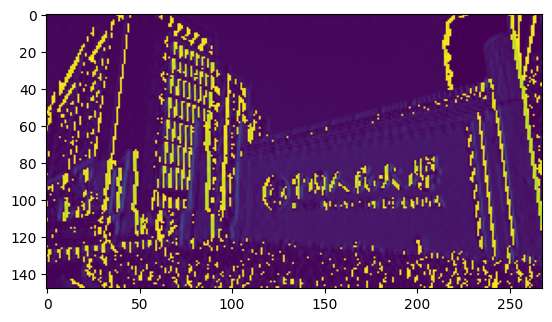

In [97]:
ker = np.array([[1,1,1,-1,-1],
                [1,0,0,0,-1],
                [1,0,0,0,-1],
                [1,0,0,0,-1],
                [1,1,1,-1,-1]])
ker2 = ker/25
ker2 = ker2.tolist()
print(ker2)

# 用ker2铺im的处理结果
im_out = conv2d(im,ker2,2)

# 显示处理后的图像
im_out = np.array(im_out)
im2 = Image.fromarray(im_out.astype('uint8'))
plt.imshow(im2)
plt.show()

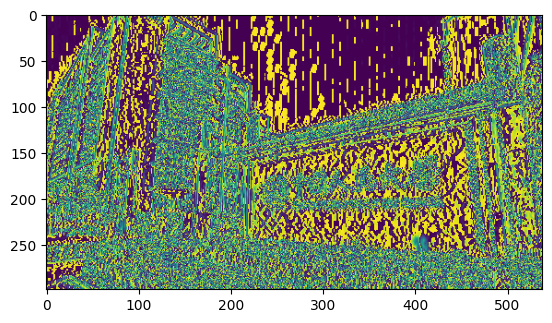

In [98]:
k3 =[[1, 0, -1], 
     [2, 0, -2], 
    [1, 0, -1]]
# 用ker2铺im的处理结果
im_out = conv2d(im,k3,1)

# 显示处理后的图像
im_out = np.array(im_out)
im2 = Image.fromarray(im_out.astype('uint8'))
plt.imshow(im2)
plt.show()

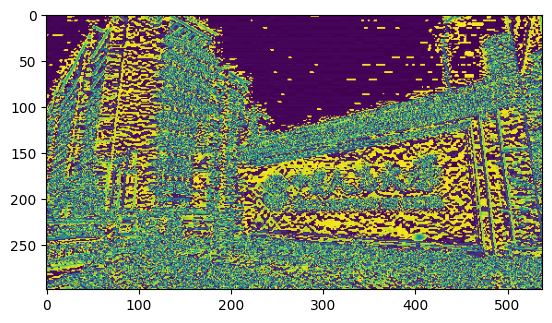

In [99]:
k3 =[[1, 2, 1], 
     [0, 0, 0], 
    [-1, -2, -1]]
# 用ker2铺im的处理结果
im_out = conv2d(im,k3,1)

# 显示处理后的图像
im_out = np.array(im_out)
im2 = Image.fromarray(im_out.astype('uint8'))
plt.imshow(im2)
plt.show()